  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Dataset shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


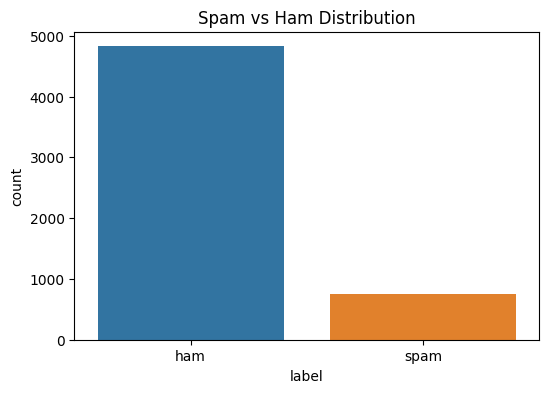


Accuracy: 0.9614349775784753

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       966
           1       0.82      0.92      0.86       149

    accuracy                           0.96      1115
   macro avg       0.90      0.94      0.92      1115
weighted avg       0.96      0.96      0.96      1115



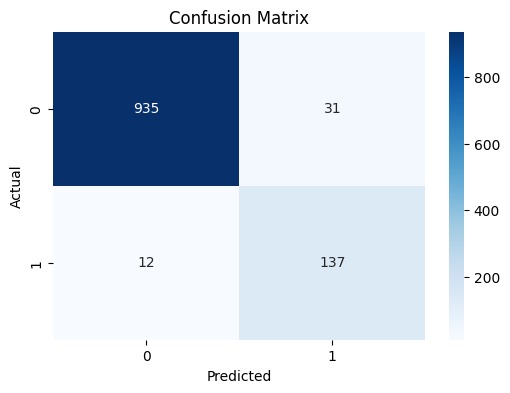

Congratulations! You won a free lottery ticket => Spam
Hey, are we meeting today? => Ham
Urgent! Click here to claim your prize => Spam
FREE FREE FREE !!! => Spam
WIN MONEY NOW!!! => Spam


In [2]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from scipy.sparse import hstack


# =========================
# STEP 2: LOAD DATA
# =========================

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_table(url, header=None, names=['label', 'message'])

print(df.head())


# =========================
# STEP 3: EDA
# =========================

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, hue='label')
plt.title("Spam vs Ham Distribution")
plt.show()


# =========================
# STEP 4: TEXT CLEANING
# =========================

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['message'].apply(clean_text)


# =========================
# STEP 5: FEATURE ENGINEERING
# =========================

df['length'] = df['message'].apply(len)
df['num_exclamation'] = df['message'].apply(lambda x: x.count('!'))
df['num_uppercase'] = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()))


# =========================
# STEP 6: LABEL ENCODING
# =========================

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

y = df['label']


# =========================
# STEP 7: TF-IDF + N-GRAMS
# =========================

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,3),
    min_df=2
)
X_text = vectorizer.fit_transform(df['cleaned'])

# Extra features
X_extra = df[['length', 'num_exclamation', 'num_uppercase']].values

# Scale extra features
scaler = StandardScaler(with_mean=False)
X_extra = scaler.fit_transform(X_extra)

# Combine features
X = hstack([X_text, X_extra])


# =========================
# STEP 8: TRAIN-TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =========================
# STEP 9: MODEL TRAINING
# =========================

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)


# =========================
# STEP 10: PREDICTION WITH THRESHOLD
# =========================

# Get probabilities
probs = model.predict_proba(X_test)[:, 1]

# Apply threshold (tune this if needed)
threshold = 0.55
y_pred = (probs > threshold).astype(int)


# =========================
# STEP 11: EVALUATION
# =========================

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# =========================
# STEP 12: REAL-TIME PREDICTION FUNCTION
# =========================

def predict_message(msg):
    msg_clean = clean_text(msg)

    text_vec = vectorizer.transform([msg_clean])

    extra_features = [[
        len(msg),
        msg.count('!'),
        sum(1 for c in msg if c.isupper())
    ]]

    extra_features = scaler.transform(extra_features)

    combined = hstack([text_vec, extra_features])

    prob = model.predict_proba(combined)[0][1]



    if prob > threshold:
        return "Spam"
    else:
        return "Ham"


# =========================
# STEP 13: TEST EXAMPLES
# =========================

samples = [
    "Congratulations! You won a free lottery ticket",
    "Hey, are we meeting today?",
    "Urgent! Click here to claim your prize",
    "FREE FREE FREE !!!",
    "WIN MONEY NOW!!!"
]

for msg in samples:
    print(msg, "=>", predict_message(msg))
